In [ ]:
# 1. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing some libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Dataset overview.

In [ ]:
df_cancer=pd.read_csv('/content/drive/MyDrive/Breast_GSE45827.csv')
df_cancer.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


###Data split.

In [ ]:
from sklearn.model_selection import train_test_split

X = df_cancer.drop(columns=['type'])
y = df_cancer['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

preprocessing on train only

In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variance filter
var_thresh = VarianceThreshold(0.01)
X_train_var = var_thresh.fit_transform(X_train)
X_test_var = var_thresh.transform(X_test)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1_macro"
    )
    return scores.mean()

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced"
)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000
)

In [ ]:
from sklearn.svm import SVC
# The 'balanced' parameter is key for small classes!
model = SVC(kernel='linear', class_weight='balanced', probability=True)
model.fit(X_train_pca, y_train)


SVC(class_weight='balanced', kernel='linear', probability=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

lr_score = evaluate_model(lr, X_train_pca, y_train)
svm_score = evaluate_model(svm, X_train_pca, y_train)

# Encode y_train for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

xgb_score = evaluate_model(xgb, X_train_pca, y_train_encoded)

print("CV Macro-F1 Scores:")
print("Logistic Regression:", lr_score)
print("SVM:", svm_score)
print("XGBoost:", xgb_score)

CV Macro-F1 Scores:
Logistic Regression: 0.9374070374070375
SVM: 0.9445498945498946
XGBoost: 0.7283749583749584


In [ ]:
lr.fit(X_train_pca, y_train)
svm.fit(X_train_pca, y_train)
xgb.fit(X_train_pca, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import f1_score

y_pred_lr = lr.predict(X_test_pca)
y_pred_svm = svm.predict(X_test_pca)
y_pred_xgb = xgb.predict(X_test_pca)

# Encode y_test for XGBoost comparison
y_test_encoded = le.transform(y_test)

print("Test Macro-F1:")
print("Logistic Regression:", f1_score(y_test, y_pred_lr, average="macro"))
print("SVM:", f1_score(y_test, y_pred_svm, average="macro"))
print("XGBoost:", f1_score(y_test_encoded, y_pred_xgb, average="macro"))

Test Macro-F1:
Logistic Regression: 0.9470614035087719
SVM: 0.9017153996101365
XGBoost: 0.7994880363301416


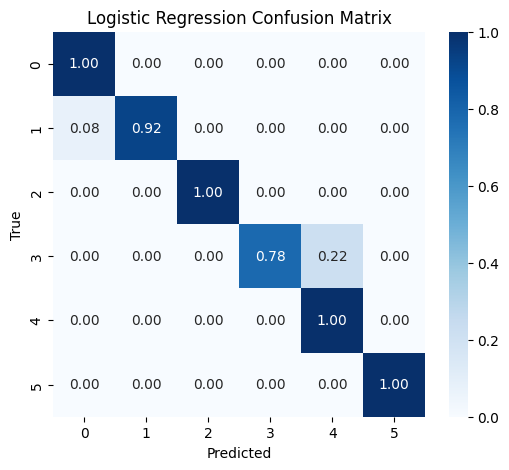

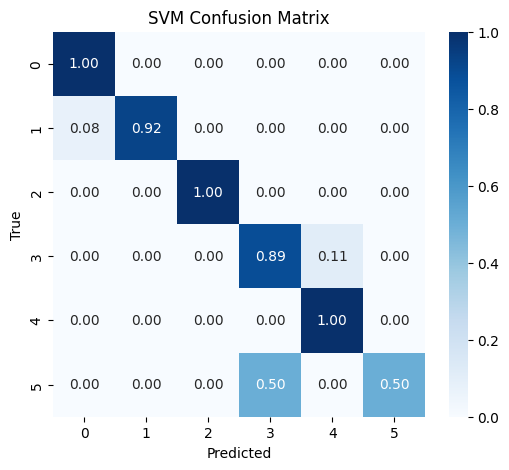

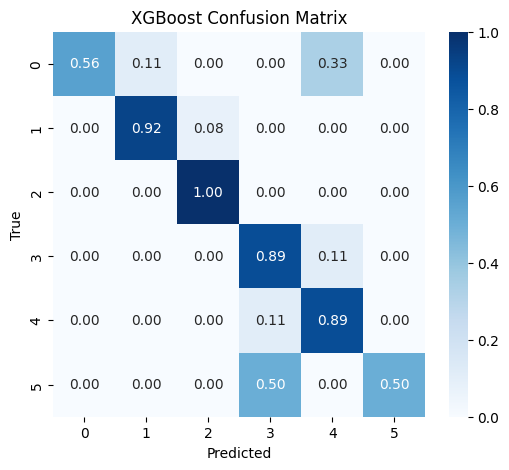

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

# Encode y_test for XGBoost confusion matrix
y_test_xgb_cm = le.transform(y_test) # Use the existing LabelEncoder 'le'

for name, preds in models.items():
    plt.figure(figsize=(6,5))
    if name == "XGBoost":
        cm = confusion_matrix(y_test_xgb_cm, preds, normalize="true")
    else:
        cm = confusion_matrix(y_test, preds, normalize="true")

    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

###Deployment demo for the app.

In [ ]:
from sklearn.svm import SVC
import joblib

# Re-train with probability enabled
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)
svm_model.fit(X_train_pca, y_train)
joblib.dump(svm_model, 'svm_model.joblib')


['svm_model.joblib']

In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.9 MB/s eta 0:00:00


In [ ]:
import joblib
# Save the variance selector you used in your workflow
joblib.dump(var_thresh, 'var_thresh.joblib')


['var_thresh.joblib']

In [ ]:
import joblib

# Replace these variable names with yours
joblib.dump(pca, 'pca_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(svm, 'svm_model.joblib')

['svm_model.joblib']

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px

# Load models
var_thresh = joblib.load('var_thresh.joblib')
scaler = joblib.load('scaler.joblib')
pca = joblib.load('pca_model.joblib')
model = joblib.load('svm_model.joblib')

st.set_page_config(layout="wide")
st.title("🧬 Precision Oncology: Genotype Classifier")

uploaded_file = st.file_uploader("Upload Patient Dataset (CSV)", type=["csv"])

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)

    # 1. SAMPLE SELECTION
    st.sidebar.header("Patient Selection")
    # Identify IDs (assumes a column named 'samples' or similar exists)
    id_col = 'samples' if 'samples' in df.columns else df.columns[0]
    selected_id = st.sidebar.selectbox("Choose Patient ID to Analyze", df[id_col].unique())

    # Filter data for just this one patient
    patient_row = df[df[id_col] == selected_id]
    X_input = patient_row.drop(columns=['type'], errors='ignore')

    try:
        # 2. PROCESSING PIPELINE
        X_selected = var_thresh.transform(X_input)
        X_scaled = scaler.transform(X_selected)
        X_pca = pca.transform(X_scaled)

        # 3. GET PROBABILITIES
        probs = model.predict_proba(X_pca)[0] # Get first row of probabilities
        classes = model.classes_
        results_df = pd.DataFrame({'Genotype': classes, 'Confidence (%)': probs * 100})
        results_df = results_df.sort_values('Confidence (%)', ascending=False)

        # 4. DISPLAY RESULTS
        col1, col2 = st.columns([1, 2])

        with col1:
            st.subheader(f"Analysis: {selected_id}")
            top_class = results_df.iloc[0]['Genotype']
            top_conf = results_df.iloc[0]['Confidence (%)']

            st.metric("Top Prediction", top_class, f"{top_conf:.1f}% Confidence")

            # Show the table of all probabilities
            st.dataframe(results_df.style.highlight_max(axis=0, color='#2ecc71'))

        with col2:
            st.subheader("Classification Probability Distribution")
            fig = px.bar(results_df, x='Confidence (%)', y='Genotype',
                         orientation='h', color='Confidence (%)',
                         color_continuous_scale='Bluered_r')
            st.plotly_chart(fig, use_container_width=True)

        # 5. FEATURE INSPECTION
        with st.expander("View Raw Gene Expression for this Patient"):
            st.line_chart(X_input.iloc[0, 1:100]) # Shows first 100 genes

    except Exception as e:
        st.error(f"Prediction Error: {e}")


Overwriting app.py


In [ ]:
from pyngrok import ngrok

# 1. Authenticate (replace with your actual token)
ngrok.set_auth_token("3C3A6hm9YOJr1tfp5wuLXJKDqwD_UEiVwAVJmDeuTtm84Cdq") # <<-- Replace this with your actual token

# 2. Run Streamlit in the background
!nohup streamlit run app.py --server.port 8501 &

# 3. Create the tunnel
public_url = ngrok.connect(8501)
print(f"Your App is live at: {public_url.public_url}")

nohup: appending output to 'nohup.out'
Your App is live at: https://preaxially-scutcheonless-so.ngrok-free.dev


The core goal of an SVM is to find the optimal hyperplane (a decision boundary) that separates different classes.Maximum Margin: SVM doesn't just draw any line; it looks for the one with the widest "street" (margin) between the classes to ensure it handles new, unseen data accurately.Support Vectors: These are the critical data points closest to the boundary. They "support" or define where the line is drawn.Kernel Trick: If your data isn't separable by a straight line, SVM uses "kernels" to project it into a higher dimension where a flat boundary can suddenly work.